In [60]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os # to use operating system dependent functionality
import librosa # to extract speech features
import wave # read and write WAV files
import matplotlib.pyplot as plt # to generate the visualizations

# MLP Classifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# LSTM Classifier
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import *
from keras.optimizers import rmsprop

# For MFCC Features
import scipy
import python_speech_features as psf 

In [61]:
def extract_mfcc(wav_file_name):
    #This function extracts mfcc features and obtain the mean of each dimension
    #Input : path_to_wav_file
    #Output: mfcc_features'''
    fs, sig = scipy.io.wavfile.read(wav_file_name)
    # get mfccs
    mfccs = psf.mfcc(sig, samplerate=fs, winlen=0.025, winstep=0.01,
                 nfilt=26, nfft=512, lowfreq=0,
                highfreq=None, preemph=0.97, ceplifter=22,
                appendEnergy=False)
    mfcc_means = np.round(mfccs.mean(axis=0), 3)
    
    return mfcc_means

In [72]:
radvess_speech_labels = [] # to save extracted label/file
ravdess_speech_data = [] # to save extracted features/file
emo = 1
for dirname, _, filenames in os.walk('F:\\Saurav\\Kushagramati\\Emotions\\'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
         # the index 7 and 8 of the file name represent the emotion label
        wav_file_name = os.path.join(dirname, filename)
        print(wav_file_name)
        
        try:
            ravdess_speech_data.append(extract_mfcc(wav_file_name)) # extract MFCC features/file
            radvess_speech_labels.append(emo)
        except:
            continue
            
    emo=emo+1    
print("Finish Loading the Dataset")

F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-01.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-02.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-03.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-04.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-05.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-06.wav


F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-07.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-08.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-09.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-10.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-11.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-12.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-13.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-14.wav


F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-15.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-16.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-17.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-18.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-19.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-20.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-21.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-22.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-23.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-01-24.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-01.wav


F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-02.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-03.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-04.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-05.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-06.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-07.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-08.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-09.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-10.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-11.wav


F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-12.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-13.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-14.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-15.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-16.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-17.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-18.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-19.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-20.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-21.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-22.wav
F:\Saurav\Kushagramati\Emotions\Angry\03-01-05-01-01-02-23.wav


...

F:\Saurav\Kushagramati\Emotions\Suprised\YAF_sub_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_such_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_sure_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_take_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_talk_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_tape_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_team_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_tell_ps.wav


F:\Saurav\Kushagramati\Emotions\Suprised\YAF_thin_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_third_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_thought_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_thumb_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_time_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_tip_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_tire_ps.wav


F:\Saurav\Kushagramati\Emotions\Suprised\YAF_ton_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_tool_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_tough_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_turn_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_vine_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_voice_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_void_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_vote_ps.wav


F:\Saurav\Kushagramati\Emotions\Suprised\YAF_wag_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_walk_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_wash_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_week_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_wheat_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_when_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_which_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_whip_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_white_ps.wav


F:\Saurav\Kushagramati\Emotions\Suprised\YAF_wife_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_wire_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_witch_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_yearn_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_yes_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_young_ps.wav
F:\Saurav\Kushagramati\Emotions\Suprised\YAF_youth_ps.wav
Finish Loading the Dataset


In [75]:
ravdess_speech_data

[array([  2.138, -16.564,  -7.645,  -0.472,  -3.458,   2.034,  -9.033,
          0.209,  -4.539,   2.006,  -3.566,  -5.908,   1.734]),
 array([-14.657, -11.113,  -4.736,  -2.637,  -3.863,   0.126, -13.171,
          0.078,  -5.299,  -4.927,  -2.511,  -0.4  ,  -1.89 ]),
 array([ 19.357, -14.531,  -6.353,  -7.066,  -5.912,   6.185,  -9.757,
         -3.746,  -0.407,  -0.75 ,  -0.751,  -1.62 ,  -1.593]),
 array([  9.362, -15.227,  -9.332,  -5.418,  -5.025,   1.593, -13.611,
         -4.375,  -3.918,  -5.861,   0.271,  -1.675,  -1.497]),
 array([ 14.277, -12.664,  -7.69 ,  -1.054,  -3.546,   8.051, -15.114,
          0.906,  -1.408,  -6.165,  -2.992,   1.101,   4.453]),
 array([  0.418, -16.578,  -2.245,  -3.459,  -1.481,  12.019,  -2.997,
         -2.269,  -3.464,  -2.482,  -1.494,  -2.04 ,   4.431]),
 array([ 20.063, -17.782,   0.581,   4.061,  -3.079,   5.817,  -7.381,
          1.837,   0.177,   0.836,  -0.112,  -1.561,  -1.135]),
 array([  5.702, -13.795,  -3.307,   0.696,  -4.563,   

In [76]:
#### convert data and label to array
ravdess_speech_data_array = np.asarray(ravdess_speech_data) # convert the input to an array
ravdess_speech_label_array = np.array(radvess_speech_labels)
ravdess_speech_label_array.shape # get tuple of array dimensions

#### make categorical labels
labels_categorical = to_categorical(ravdess_speech_label_array) # converts a class vector (integers) to binary class matrix
ravdess_speech_data_array.shape
labels_categorical.shape

(11803, 9)

# MLP Classifier

In [77]:
x_train,x_test,y_train,y_test= train_test_split(np.array(ravdess_speech_data_array),labels_categorical, test_size=0.20, random_state=9)

In [78]:
# Initialize the Multi Layer Perceptron Classifier
model=MLPClassifier(alpha=0.01, batch_size=256, epsilon=1e-08, hidden_layer_sizes=(300,), learning_rate='adaptive', max_iter=500)

In [79]:
# Train the model
model.fit(x_train,y_train)

MLPClassifier(alpha=0.01, batch_size=256, hidden_layer_sizes=(300,),
              learning_rate='adaptive', max_iter=500)

In [80]:
# Predict for the test set
y_pred=model.predict(x_test)

In [81]:
# Calculate the accuracy of our model
accuracy=accuracy_score(y_true=y_test, y_pred=y_pred)
# Print the accuracy
print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: 41.72%


# LSTM Model

In [82]:
# Split the training, validating, and testing sets
number_of_samples = ravdess_speech_data_array.shape[0]
training_samples = int(number_of_samples * 0.8)
validation_samples = int(number_of_samples * 0.1)
test_samples = int(number_of_samples * 0.1)

In [87]:
# Define the LSTM model
def create_model_LSTM():
    model = Sequential()
    model.add(LSTM(128, return_sequences=False, input_shape=(13, 1)))
    model.add(Dense(64))
    model.add(Dropout(0.4))
    model.add(Activation('relu'))
    model.add(Dense(32))
    model.add(Dropout(0.4))
    model.add(Activation('relu'))
    model.add(Dense(9))
    model.add(Activation('softmax'))
    
    # Configures the model for training
    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
    return model

In [88]:
### train using LSTM model
model_A = create_model_LSTM()
history = model_A.fit(np.expand_dims(ravdess_speech_data_array[:training_samples],-1), labels_categorical[:training_samples], validation_data=(np.expand_dims(ravdess_speech_data_array[training_samples:training_samples+validation_samples], -1), labels_categorical[training_samples:training_samples+validation_samples]), epochs=100, shuffle=True)

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Train on 9442 samples, validate on 1180 samples
Epoch 1/100
9442/9442 [==============================] - 7s 712us/step - loss: 1.7577 - acc: 0.2486 - val_loss: 4.6174 - val_acc: 0.0000e+00
Epoch 2/100
9442/9442 [==============================] - 3s 366us/step - loss: 1.5555 - acc: 0.3097 - val_loss: 5.7987 - val_acc: 0.0000e+00
Epoch 3/100
9442/9442 [==============================] - 3s 366us/step - loss: 1.4495 - acc: 0.3766 - val_loss: 6.0240 - val_acc: 0.0000e+00
Epoch 4/100
9442/9442 [==============================] - 3s 368us/step - loss: 1.3717 - acc: 0.4158 - val_loss: 6.7763 - val_acc: 0.0000e+00
Epoch 5/100
9442/9442 [==============================] - 4s 374us/step - loss: 1.3086 - acc: 0.4441 - val_loss: 6.5272 - val_acc: 0.0000e+00
Epoch 6/100
9442/9442 [==============================] - 4s 376us/step - loss: 1.2622 - acc: 0.4639 - val_loss: 7.3546 - val_acc: 0.0169
Epoch 7/100
9442/9442 [==============================] - 4s 371us/step - loss: 1.2229 - acc: 0.4879 - val_loss

9442/9442 [==============================] - 3s 366us/step - loss: 0.7059 - acc: 0.7115 - val_loss: 13.9084 - val_acc: 0.0144
Epoch 60/100
9442/9442 [==============================] - 3s 363us/step - loss: 0.7234 - acc: 0.7056 - val_loss: 11.2983 - val_acc: 0.0220
Epoch 61/100
9442/9442 [==============================] - 3s 366us/step - loss: 0.6968 - acc: 0.7207 - val_loss: 13.6740 - val_acc: 0.0237
Epoch 62/100
9442/9442 [==============================] - 4s 372us/step - loss: 0.7069 - acc: 0.7167 - val_loss: 13.4530 - val_acc: 0.0220
Epoch 63/100
9442/9442 [==============================] - 3s 338us/step - loss: 0.6791 - acc: 0.7270 - val_loss: 14.1748 - val_acc: 0.0161
Epoch 64/100
9442/9442 [==============================] - 4s 373us/step - loss: 0.7031 - acc: 0.7212 - val_loss: 13.8687 - val_acc: 0.0220
Epoch 65/100
9442/9442 [==============================] - 4s 390us/step - loss: 0.6704 - acc: 0.7335 - val_loss: 13.5428 - val_acc: 0.0178
Epoch 66/100
9442/9442 [================

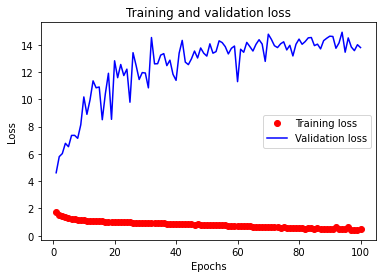

In [89]:
### loss plots using LSTM model
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()